In [1]:
""" !pip install -r requirements.txt """

' !pip install -r requirements.txt '

# Import Libraries

In [2]:
import os
import time
import pickle
import random
import itertools

# Analisi dati e Visualizzazione
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: Preprocessing e Dimensionality Reduction
from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    LabelEncoder,
    OneHotEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight

# Scikit-learn: Model Selection e Pipeline
from sklearn.model_selection import (
    train_test_split,
    PredefinedSplit,
    GridSearchCV,
    RandomizedSearchCV
)
from sklearn.pipeline import Pipeline

# Scikit-learn: Modelli di Machine Learning Classico
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import plot_tree

# Imbalanced Learning (SMOTE e Pipeline compatibile)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Metriche di Valutazione
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    PrecisionRecallDisplay
)

# Deep Learning (PyTorch) e Monitoraggio
""" import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter """


# Our packages
from utils import *
from plot import *

# Global Variables

In [3]:
seed = 42
FILENAME = "../../data/train.csv"

# Load the dataset

In [4]:
df = pd.read_csv(FILENAME, encoding='ISO-8859-1', sep=",")

rows = df.shape[0]
cols = df.shape[1]
print("# Righe: " + str(rows)+ " # Colonne: "+str(cols) + "\n")

# Righe: 148301 # Colonne: 145



# Preprocessing

## 1. Remove duplicates

In [5]:
# Individua se esistono colonne con lo stesso nome
# Se esistono, allora se le colonne sono duplicati perfetti, droppiamo il duplicato
# Se esistono, ma nono sono perfetti duplicati, per intervenire consciamente sarebbe necessario avere maggior domain knowledge
feature_list = df.columns.to_list()
has_duplicate_cols = len(feature_list) != len(set(feature_list))
print("Ci sono colonne con lo stesso nome?", has_duplicate_cols)

if has_duplicate_cols:
    df2 = df.T.drop_duplicates().T


# Rimuovi righe duplicate
df.drop_duplicates(inplace=True)


Ci sono colonne con lo stesso nome? False


## 2. Label extraction

In [6]:
X = df.drop(columns=["grade"])
y = df["grade"]

In [7]:
print(X['hardship_type_label'].unique())
print(X['hardship_loan_status_label'].unique())
print(X['hardship_status_label'].unique())

<StringArray>
[nan, 'interest only-3 months deferral']
Length: 2, dtype: str
<StringArray>
[                 nan,            'current',  'late (16-30 days)',
    'in grace period', 'late (31-120 days)',             'issued']
Length: 6, dtype: str
<StringArray>
[nan, 'completed', 'broken', 'active']
Length: 4, dtype: str


## 3. Data visualization

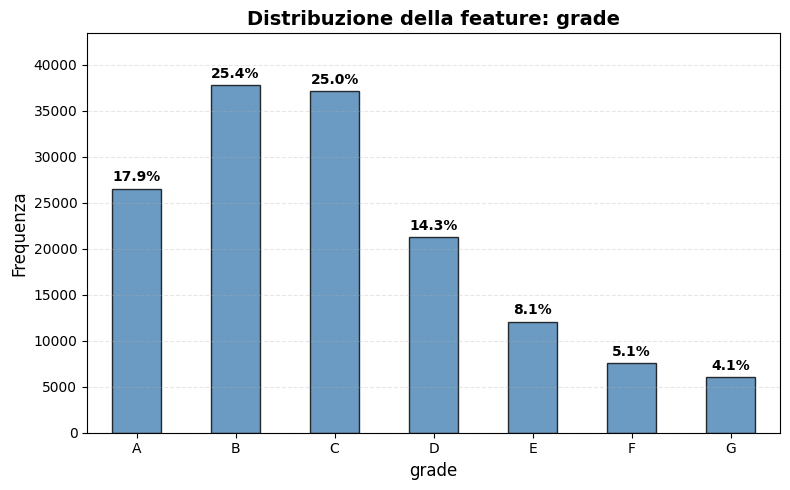

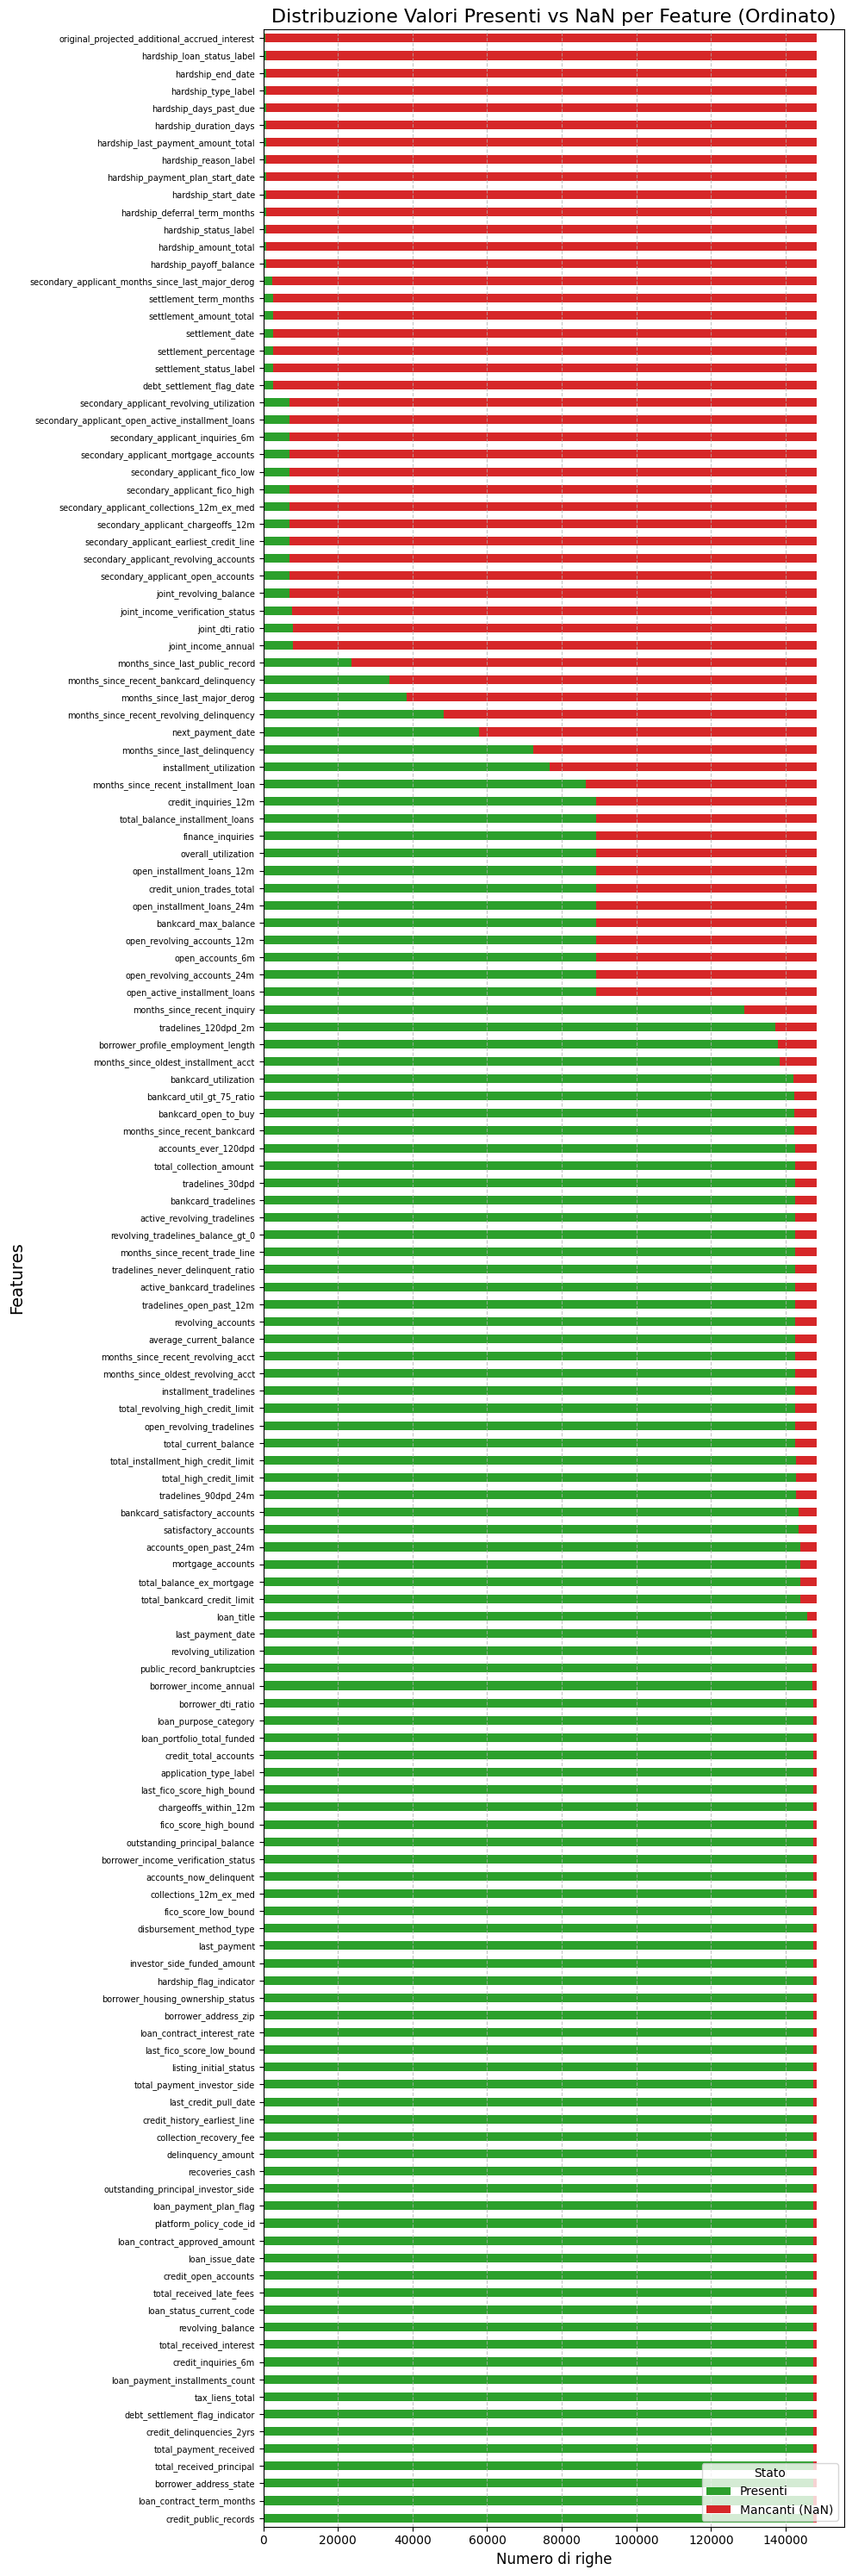

In [8]:
plot_feature_distribution(y, "grade")
plot_nan(X)

## 4. Features manipulation

In [9]:
for i in X.dtypes.unique():
    print("Type", i)

Type float64
Type str


In [10]:
# Teniamo una flag per indicare se un hardship loan e' stato concesso o meno
# X['has_hardship_plan'] = X['hardship_start_date'].notna().astype(float)

In [11]:
X = drop_high_nan_columns(X, 0.50)

Colonne rimosse (> 50.0% NaN):
['months_since_last_delinquency', 'months_since_last_public_record', 'next_payment_date', 'months_since_last_major_derog', 'joint_income_annual', 'joint_dti_ratio', 'joint_income_verification_status', 'months_since_recent_bankcard_delinquency', 'months_since_recent_revolving_delinquency', 'joint_revolving_balance', 'secondary_applicant_fico_low', 'secondary_applicant_fico_high', 'secondary_applicant_earliest_credit_line', 'secondary_applicant_inquiries_6m', 'secondary_applicant_mortgage_accounts', 'secondary_applicant_open_accounts', 'secondary_applicant_revolving_utilization', 'secondary_applicant_open_active_installment_loans', 'secondary_applicant_revolving_accounts', 'secondary_applicant_chargeoffs_12m', 'secondary_applicant_collections_12m_ex_med', 'secondary_applicant_months_since_last_major_derog', 'hardship_type_label', 'hardship_reason_label', 'hardship_status_label', 'hardship_deferral_term_months', 'hardship_amount_total', 'hardship_start_date'

### Categorical features

In [12]:
##### FEATURES EXTRACTION ######
# Trasforma "36 months" e "60 months" in float type
print("\n", X['loan_contract_term_months'].unique())
X['loan_contract_term_months'] = X['loan_contract_term_months'].str.extract(r'(\d+)').astype(float)

# Strip della stringa "years"
# Trasforma anni in float: < 1 diventa 0, 10+ diventa 10
print("\n", X['loan_contract_term_months'].unique())
X['borrower_profile_employment_length'] = X['borrower_profile_employment_length'].str.replace(r'\+? years?', '', regex=True)
X['borrower_profile_employment_length'] = X['borrower_profile_employment_length'].replace({ '< 1': 0}).astype(float)


##### DROP FEATURES #####
categorical_to_drop = [
  'loan_title',                         # non significant column, grande sparsita' di dati. Sufficiente loan_purpose_category come aggregazione di scopo del prestito
  'borrower_address_zip',               # non significant column, esiste una colonna per identificazione stati
]

X = X.drop(columns=categorical_to_drop)


 <StringArray>
[' 36 months', ' 60 months', nan]
Length: 3, dtype: str

 [36. 60. nan]


### Numerical features

In [13]:
# 1. DROP: Data Leakage (Future Information)
numerical_to_drop = [
    # Future income for loaner
    'total_payment_received', 'total_received_principal', 'recoveries_cash',
    'collection_recovery_fee', 'last_payment', 'outstanding_principal_balance',
    'total_received_interest', 'total_received_late_fees',
]

X = X.drop(columns=numerical_to_drop)


print("Nuovo # Colonne: " +  str(X.shape[1]) + "\n")

Nuovo # Colonne: 92



In [14]:
# 2. DROP: Secondary/Joint Applicant info
# application_type_label ci informa gia' se il tipo di prestito e' individual o

joint_and_secondary_cols = [col for col in X.columns if col.startswith('joint_') or col.startswith('secondary_')]

# DROP: tutti i campi relativi a settlement sono data leakage
settlement_cols = [col for col in X.columns if 'settlement' in col]

to_drop = joint_and_secondary_cols + settlement_cols

X = X.drop(columns=to_drop)

print("Nuovo # Colonne: " +  str(X.shape[1]) + "\n")

Nuovo # Colonne: 91



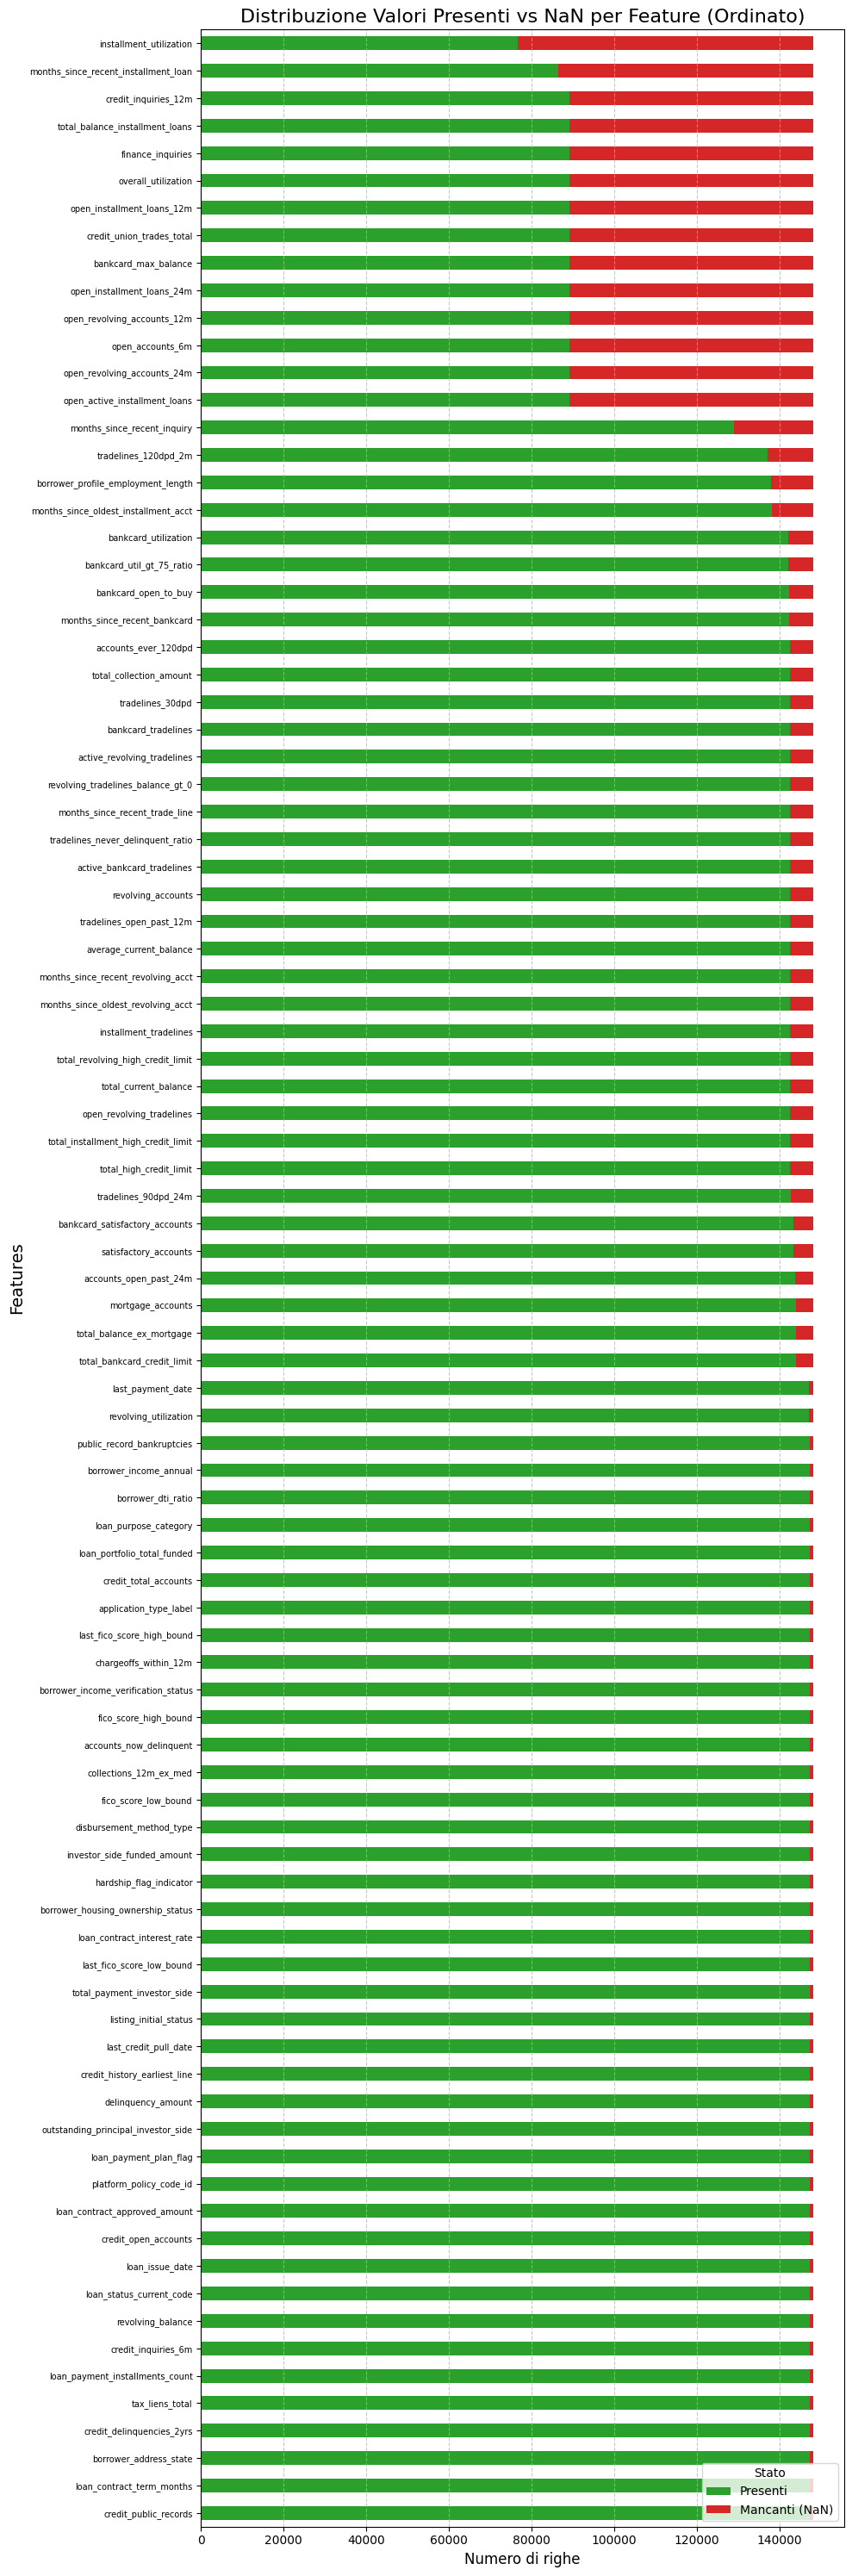

In [15]:
plot_nan(X)

In [16]:
# Feature categoriche in cui i valori NaN sono riempiti con una nuova label Unknown
categorical_to_unknown = [
  'borrower_address_state',
  'loan_purpose_category',
  'loan_status_current_code',
  'borrower_income_verification_status',
  'borrower_housing_ownership_status'
]

# 2. Fill with 'unknown'
unknown_cols = [col for col in categorical_to_unknown if col in X.columns]
X[unknown_cols] = X[unknown_cols].fillna('unknown')


# 3. KEEP & FILL: "Months Since" columns (NaN = Never happened)
# We fill with a large number (e.g., 100 months) to signify "very long time ago / never"
structural_cols = [
    'months_since_last_public_record',
    'months_since_recent_bankcard_delinquency',
    'months_since_last_major_derog',
    'months_since_recent_revolving_delinquency',
    'months_since_last_delinquency'
]

structural = [col for col in structural_cols if col in X.columns]
X[structural] = X[structural].fillna(100)


In [17]:
##### DATES #####
X['loan_issue_date'] = pd.to_datetime(X['loan_issue_date'], format='%b-%Y')

X['issue_month'] = X['loan_issue_date'].dt.month
X['issue_year'] = X['loan_issue_date'].dt.year

# cyclical Encoding
X['issue_month_sin'] = np.sin(2 * np.pi * X['issue_month'] / 12)
X['issue_month_cos'] = np.cos(2 * np.pi * X['issue_month'] / 12)

# calculate
X['credit_history_earliest_line'] = pd.to_datetime(X['credit_history_earliest_line'], format='%b-%Y')

# Numero mesi passati tra prima richiesta credito e loan date
X['months_since_earliest_cr_line'] = (
    (X['loan_issue_date'].dt.year - X['credit_history_earliest_line'].dt.year) * 12 +
    (X['loan_issue_date'].dt.month - X['credit_history_earliest_line'].dt.month)
)


# Tutte le features rimanenti con date non sono rilevanti (leakage)
date_cols = [col for col in X.columns if 'date' in col]
to_drop = [
    'credit_history_earliest_line',     # used for feature extraction
    'issue_month',                      # used for feature extraction: sin/cos encoding
    ] + date_cols


X = X.drop(columns=to_drop)
print(f"Columns remaining: {X.shape[1]}")

Columns remaining: 91


## NaN management

In [18]:
print_nan(X)

                             Feature    Type   Nan Percentuale NaN (%)  Uniques Count                                                                                                                                                                                                                             Unique Values
           loan_contract_term_months float64   890               0.60%              2                                                                                                                                                                                                      [np.float64(36.0), np.float64(60.0)]
              loan_payment_plan_flag     str   949               0.64%              2                                                                                                                                                                                                                                ['n', 'y']
              listing_initial_status    

In [19]:
# Split train test: 0.25
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, stratify=y, random_state=seed)

In [20]:
# 1. Definiamo il valore soglia (es. 0.05 o 0.20)
correlation_threshold = 0.1

# 2. Prepariamo il target numerico (necessario per il calcolo della correlazione)
# Assicurati che y_train sia la serie originale con i gradi 'A', 'B', etc.
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
y_numeric = y_train.map(grade_map)

# 3. Calcoliamo la correlazione solo per le colonne numeriche
X_numeric = X_train.select_dtypes(include=['float', 'int'])
correlations = X_numeric.corrwith(y_numeric)

# 4. Identifichiamo le colonne da eliminare
# Selezioniamo le colonne dove il valore assoluto della correlazione è INFERIORE alla soglia
to_drop = correlations[correlations.abs() < correlation_threshold].index.tolist()

print(f"Soglia impostata: {correlation_threshold}")
print(f"Numero di colonne da eliminare: {len(to_drop)}")
print(f"Esempi di colonne eliminate: {to_drop[:5]}")

# 5. Eseguiamo il drop effettivo su Train e Validation
# Usiamo errors='ignore' per evitare errori se eseguiamo la cella due volte
X_train = X_train.drop(columns=to_drop)
X_val = X_val.drop(columns=to_drop)

print(f"\nShape finale X_train: {X_train.shape}")
print(f"Shape finale X_val: {X_val.shape}")

Soglia impostata: 0.1
Numero di colonne da eliminare: 43
Esempi di colonne eliminate: ['borrower_profile_employment_length', 'borrower_income_annual', 'credit_delinquencies_2yrs', 'credit_open_accounts', 'credit_public_records']

Shape finale X_train: (111225, 48)
Shape finale X_val: (37076, 48)


In [21]:
# Feature categoriche in cui i valori NaN possono essere riempiti con la moda:
# valori con 2 etichette, in cui la mancanza di un dato viene trattato come "no" o come occorrenza piu' frequente
fill_to_mode =[
  # Categorical
  'disbursement_method_type',
  'application_type_label',
  'listing_initial_status',
  'loan_payment_plan_flag',
  'hardship_flag_indicator',      # n/y
  'loan_payment_plan_flag',       # n/y

  # Numerical
  'loan_contract_term_months'  # 36/60 mesi
]

for i in fill_to_mode:
    print(X[i].unique())


# 1. Setup the imputer with 'most_frequent' (Mode)
mode_imputer = SimpleImputer(strategy='most_frequent')

# 2. Fit on TRAIN only (Learn the most common categories)
# It's important to select only these columns to avoid errors with other types
mode_imputer.fit(X_train[fill_to_mode])

# 3. Transform BOTH (Fill NaNs)
# We assign the result back to the specific columns to keep the DataFrame structure
X_train[fill_to_mode] = mode_imputer.transform(X_train[fill_to_mode])
X_val[fill_to_mode] = mode_imputer.transform(X_val[fill_to_mode])

<StringArray>
['cash', 'directpay', nan]
Length: 3, dtype: str
<StringArray>
['individual', 'joint app', nan]
Length: 3, dtype: str
<StringArray>
['f', 'w', nan]
Length: 3, dtype: str
<StringArray>
['n', nan, 'y']
Length: 3, dtype: str
<StringArray>
['n', nan, 'y']
Length: 3, dtype: str
<StringArray>
['n', nan, 'y']
Length: 3, dtype: str
[36. 60. nan]


In [22]:

""" numerical_to_mean = [
    'borrower_dti_ratio',
    'borrower_income_annual',
    'revolving_utilization',
    'total_revolving_high_credit_limit',
] """

numerical_to_median = X_train.select_dtypes(include=['float', 'int']).columns

# Setup the imputer
# Fill with median values to not influence skewed data
imputer = SimpleImputer(strategy='median')

# Fit on TRAIN only (Learn the medians)
imputer.fit(X_train[numerical_to_median])

# Transform BOTH (Fill NaNs)
X_train[numerical_to_median] = imputer.transform(X_train[numerical_to_median])
X_val[numerical_to_median] = imputer.transform(X_val[numerical_to_median])

In [23]:
""" print_nan(X_train)
plot_nan(X_train)

print_nan(X_val)
plot_nan(X_val) """

' print_nan(X_train)\nplot_nan(X_train)\n\nprint_nan(X_val)\nplot_nan(X_val) '

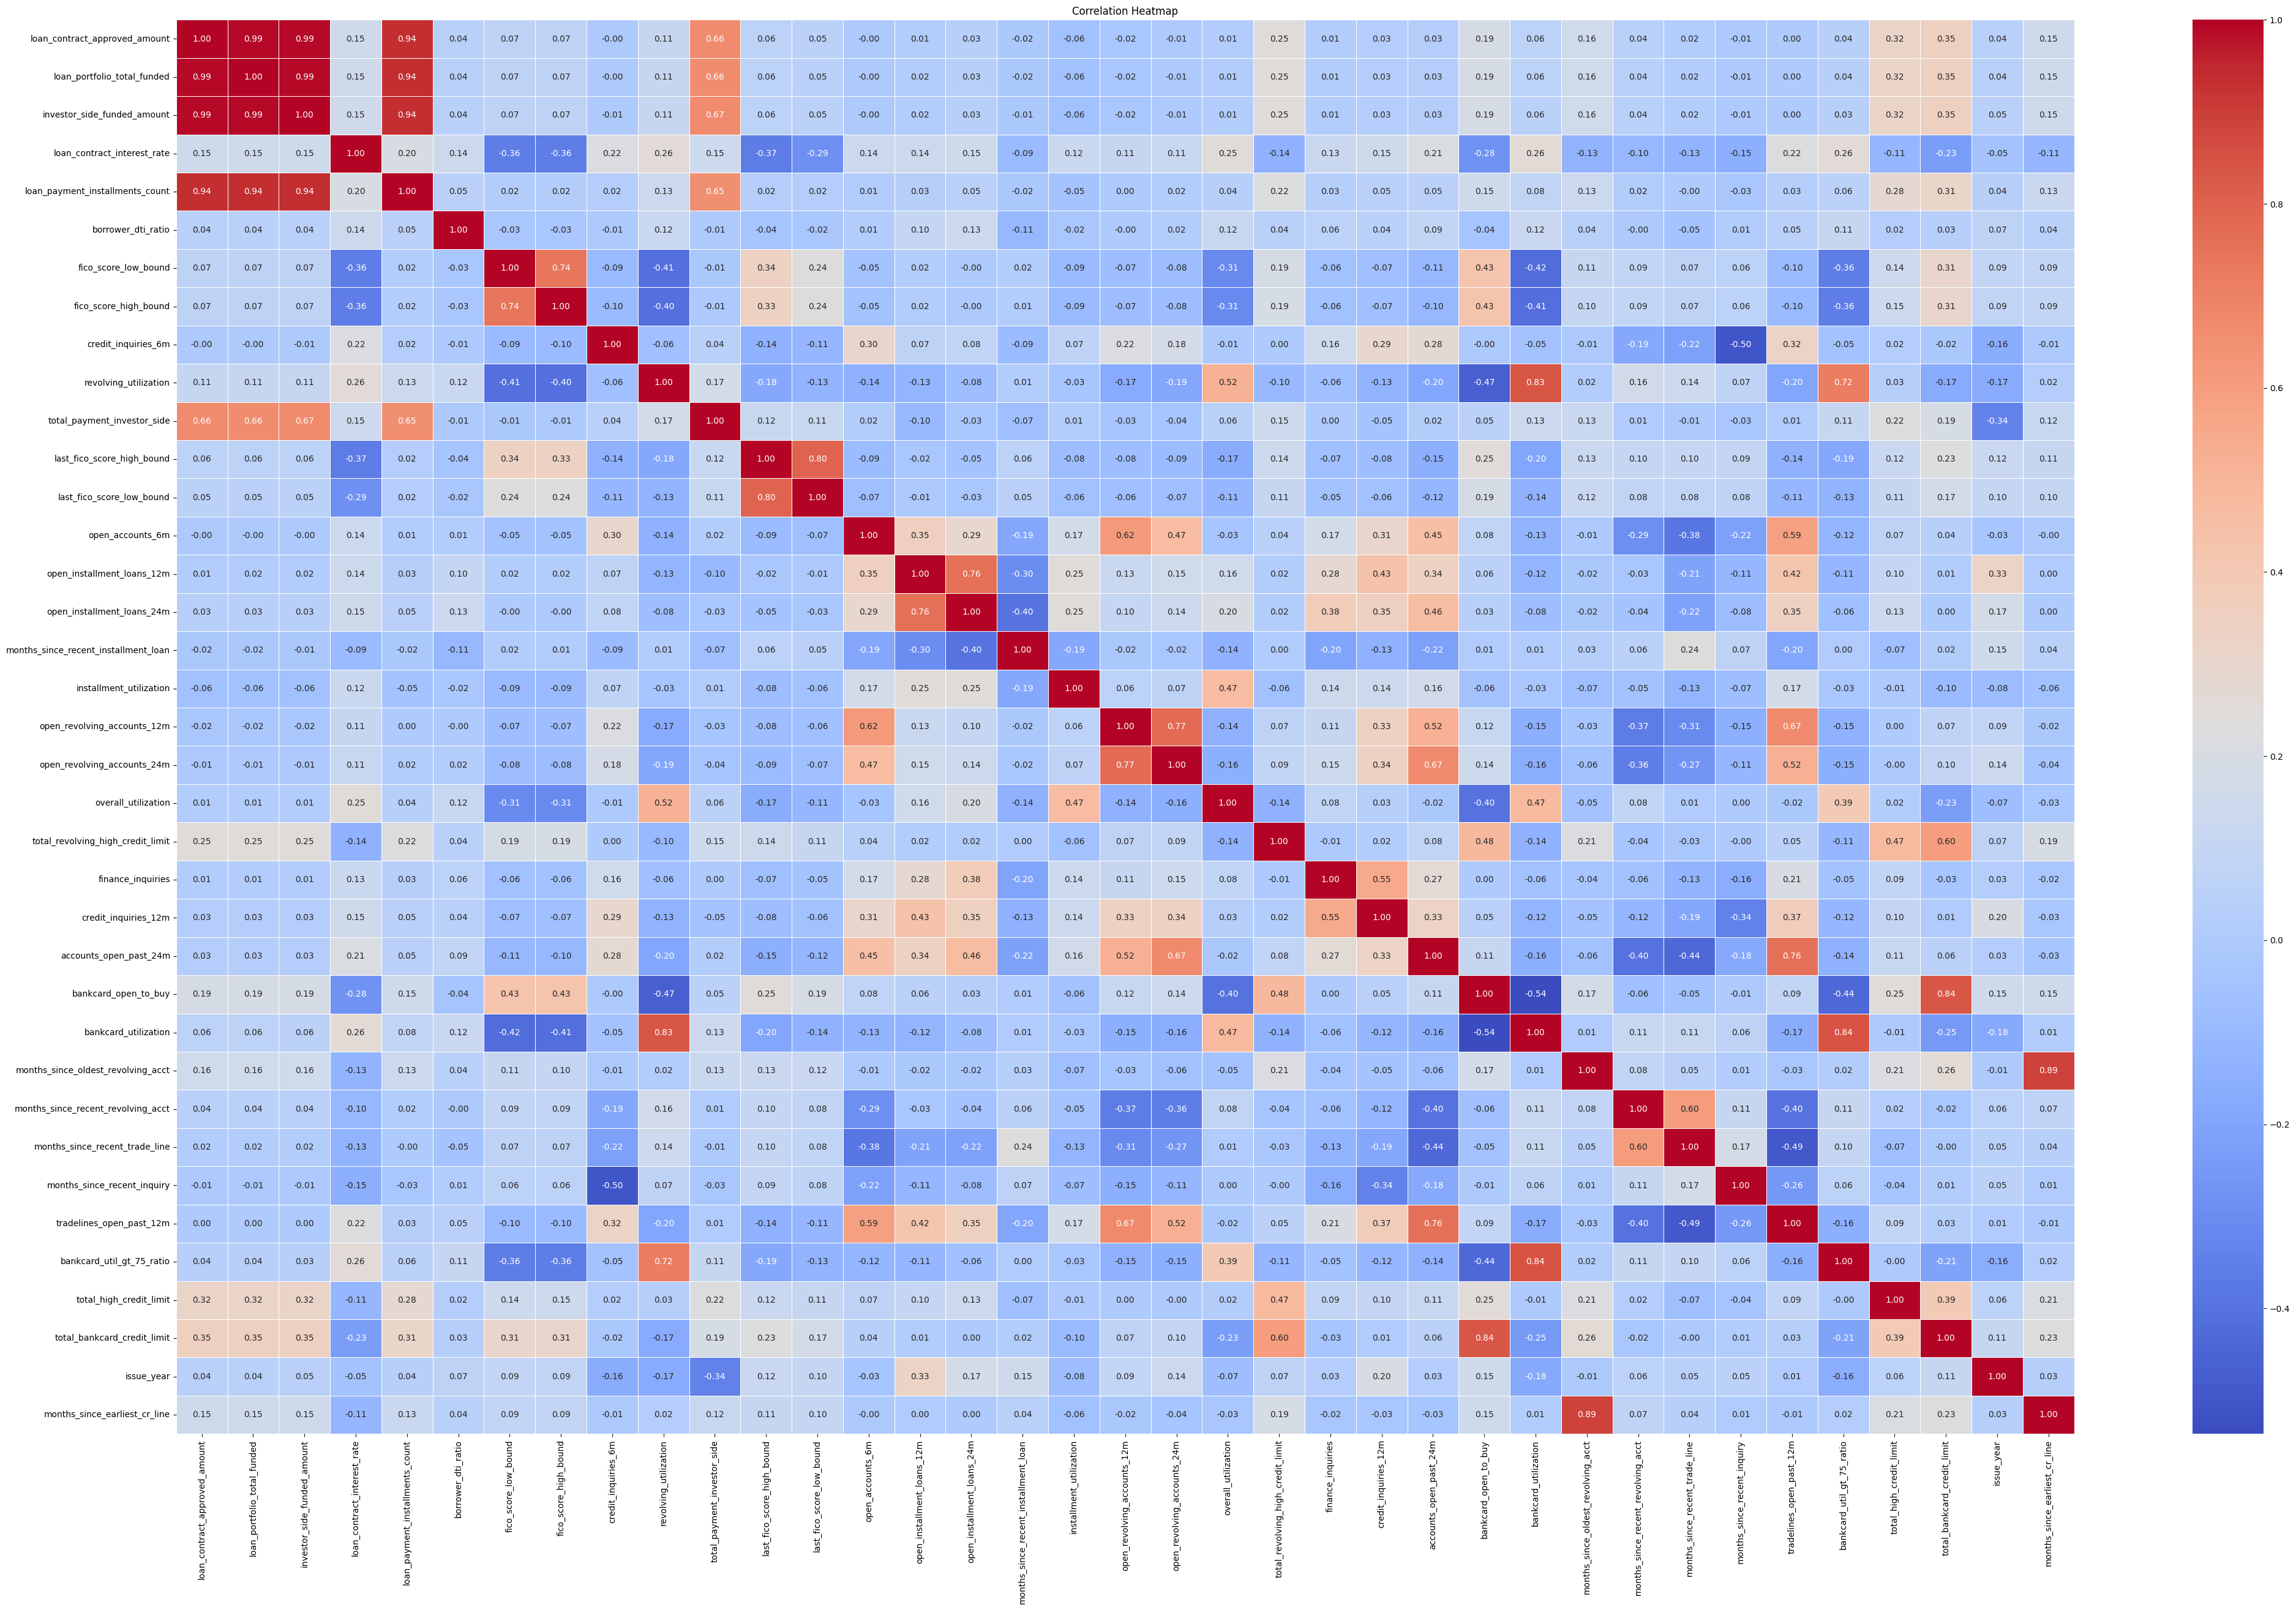

In [24]:
corr_columns = X_train.select_dtypes(include=['float', 'int'])
matrix = corr_columns.corr()

plt.figure(figsize=(50 ,30))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


In [25]:
num_cols = X_train.select_dtypes(include=['float64', 'int64'])
#analyze_feature_distributions(num_cols, save_plots=False, output_folder="grafici_explorativi")

In [26]:
""" num_cols = X_train.select_dtypes(include=['float64', 'int64'])
df_transformed, report = auto_transform_features(num_cols)

print("Riepilogo Trasformazioni:")
print(report.head(20)) """

' num_cols = X_train.select_dtypes(include=[\'float64\', \'int64\'])\ndf_transformed, report = auto_transform_features(num_cols)\n\nprint("Riepilogo Trasformazioni:")\nprint(report.head(20)) '

In [27]:
""" aaa = identify_distributions(X_train)
print(aaa.to_string()) """

' aaa = identify_distributions(X_train)\nprint(aaa.to_string()) '

In [28]:
X_train = apply_capping(X_train, 0.01, 0.99)

Colonna 'loan_contract_approved_amount': cappata tra 1600.00 e 40000.00
Colonna 'loan_portfolio_total_funded': cappata tra 1600.00 e 40000.00
Colonna 'investor_side_funded_amount': cappata tra 1500.00 e 40000.00
Colonna 'loan_contract_interest_rate': cappata tra 5.32 e 30.84
Colonna 'loan_payment_installments_count': cappata tra 54.67 e 1248.82
Colonna 'borrower_dti_ratio': cappata tra 1.77 e 43.63
Colonna 'fico_score_low_bound': cappata tra 613.25 e 810.00
Colonna 'fico_score_high_bound': cappata tra 617.50 e 814.00
Colonna 'credit_inquiries_6m': cappata tra 0.00 e 4.00
Colonna 'revolving_utilization': cappata tra 0.80 e 98.80
Colonna 'total_payment_investor_side': cappata tra 579.77 e 44677.51
Colonna 'last_fico_score_high_bound': cappata tra 499.00 e 826.61
Colonna 'last_fico_score_low_bound': cappata tra 0.00 e 824.69
Colonna 'open_accounts_6m': cappata tra 0.00 e 4.00
Colonna 'open_installment_loans_12m': cappata tra 0.00 e 4.00
Colonna 'open_installment_loans_24m': cappata tra 0.

In [29]:
num_cols = X_train.select_dtypes(include=['float64', 'int64'])
#analyze_feature_distributions(num_cols, save_plots=False, output_folder="grafici_explorativi")

## Features encoding

In [30]:

categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Create encoder with handle_unknown to deal with unseen categories
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit on training data only
ohe.fit(X_train[categorical_features])

# Transform both sets
X_train_encoded = ohe.transform(X_train[categorical_features])
X_val_encoded = ohe.transform(X_val[categorical_features])

# Get feature names for the encoded columns
encoded_feature_names = ohe.get_feature_names_out(categorical_features)

# Create DataFrames with the encoded features
X_train_ohe = pd.DataFrame(X_train_encoded,
                           columns=encoded_feature_names,
                           index=X_train.index)
X_val_ohe = pd.DataFrame(X_val_encoded,
                         columns=encoded_feature_names,
                         index=X_val.index)

# Drop original categorical columns and concatenate encoded ones
X_train = X_train.drop(columns=categorical_features).join(X_train_ohe)
X_val = X_val.drop(columns=categorical_features).join(X_val_ohe)


le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)


print(X_train.shape[1])
print(X_train.head())

/tmp/ipykernel_5444/3585451326.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns.tolist()


136
        loan_contract_approved_amount  loan_portfolio_total_funded  \
27319                          8000.0                  8636.284704   
92768                         10000.0                 10000.000000   
47317                         14700.0                 14700.000000   
114343                        14000.0                 12535.938009   
64675                         25000.0                 25000.000000   

        investor_side_funded_amount loan_contract_term_months  \
27319                    8000.00000                      36.0   
92768                   10588.35588                      60.0   
47317                   14700.00000                      36.0   
114343                  14000.00000                      60.0   
64675                   25000.00000                      36.0   

        loan_contract_interest_rate  loan_payment_installments_count  \
27319                         14.46                           275.22   
92768                         22.99     

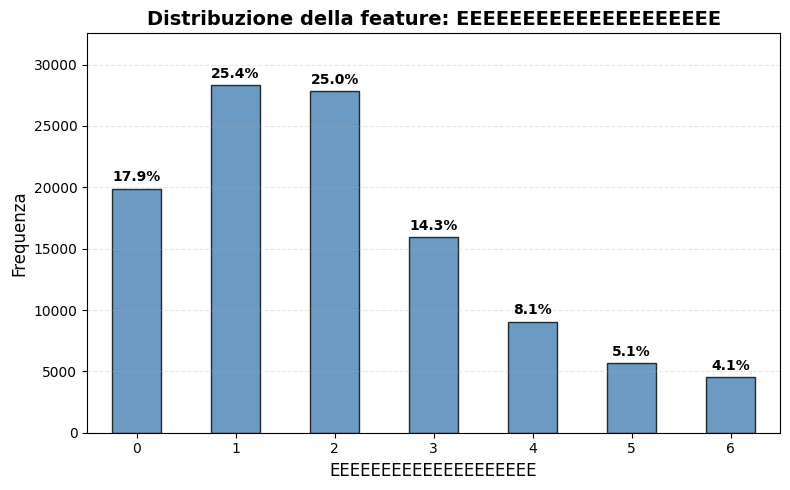

In [31]:
plot_feature_distribution(y_train, "EEEEEEEEEEEEEEEEEEEE")

# Training

## Define the scalers to be used

In [32]:
# Scalers to test
scalers = {
    "MinMaxScaler": MinMaxScaler(),
    #"StandardScaler": StandardScaler()
}

## Apply Random Forests with hyperparameters tuning

In [ ]:
''' param_grid_rf = {
    'clf__n_estimators': [100],
    'clf__max_depth': [5],
    #'clf__max_features': [None, 'sqrt', 'log2'],
    #'clf__criterion': ['gini', 'entropy', 'log_loss'],
    #'clf__max_depth': [None, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
}
 '''

param_grid_rf = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_features': ['sqrt', 'log2'],
    'clf__criterion': ['gini', 'entropy', 'log_loss'],
    'clf__max_depth': [None, 10, 20]
}

pipeline = Pipeline([
    ("clf", RandomForestClassifier(random_state=seed, n_jobs=-1, class_weight='balanced'))        #No oversampling needed in random forest (?)
])

grid = GridSearchCV(pipeline, param_grid_rf, cv=5, scoring='balanced_accuracy', n_jobs=-1, verbose=3)
grid.fit(X_train, y_train)

print("Performance:", grid.best_estimator_)
print("Performance:", grid.best_params_)

with open("rf.save","wb") as file:
    pickle.dump(grid.best_estimator_['clf'], file)

In [ ]:
evaluate_model("rf.save", X_val, y_val, "Random Forest (Best)")

In [ ]:
visualize_rf_tree("rf.save", X_train, y_train, max_depth=5)

In [ ]:
plot_top_correlations_split(X_train, y_train)

## Apply Support Vector Classifier with hyperparameters tuning

In [ ]:
# SVC param grid
# L' uso di LinearSVC su classic SVC (inserire differenza) e' necessario causa n_sample esteso (si consiglia se > 10k-ish)
param_grid_svc = {
    'clf__C': [20],      #[0.1, 1, 10, 100, 1000],
    'clf__kernel': ["rbf"]     #, "poly"
    }

""" param_grid_lsvc = {
    'clf__C': [30, 40, 50, 100],
    'clf__max_iter': [250, 500, 750]
} """

# Grid Search with Pipeline
best_score = 0
for scaler_name, scaler in scalers.items():

        pipeline = Pipeline([
            # 1. Scale first (LinearSVC needs it)
            ('scaler', scaler),

            # 2. SMOTE inside the fold (Prevents leakage!)
            #('smote', SMOTE(random_state=seed)),

            ("clf", SVC(class_weight="balanced", random_state=seed))

            # 3. Use Fast LinearSVC
            #('clf', LinearSVC(dual=False, loss='squared_hinge', class_weight='balanced', random_state=seed))             #Prefer dual=False when n_samples > n_features
        ])

        # Perform Grid Search
        grid =  GridSearchCV(pipeline, param_grid_svc, cv=3, scoring='balanced_accuracy', n_jobs=-1, verbose=3)
        grid.fit(X_train, y_train)


        print("Performance:", grid.best_estimator_)
        print("Performance:", grid.best_params_)


        if grid.best_score_ > best_score:
            best_score = grid.best_score_
            with open("svc_scaler.save","wb") as file:
                pickle.dump(grid.best_estimator_['scaler'], file)
            with open("svc.save","wb") as file:
                pickle.dump(grid.best_estimator_['clf'], file)


In [ ]:
evaluate_model("svc.save", X_val, y_val, "SVC")

## Apply K Neighbors Classifier with hyperparameters tuning

In [ ]:
# KNN param grid
param_grid_knn = {
    'clf__n_neighbors': [15],
    'clf__weights': ['distance'],
    'clf__metric': ['manhattan']
}
# Grid Search with Pipeline
best_score = 0
for scaler_name, scaler in scalers.items():

        pipeline = ImbPipeline([
            ('scaler', MinMaxScaler()),
            ('smote', SMOTE(random_state=seed)),
            ('clf', KNeighborsClassifier(n_jobs=-1))
        ])

        # Perform Grid Search
        grid =  GridSearchCV(pipeline, param_grid_knn, cv=5, scoring='balanced_accuracy', n_jobs=-1, verbose=3)
        grid.fit(X_train, y_train)


        print("Performance:", grid.best_estimator_)
        print("Performance:", grid.best_params_)


        if grid.best_score_ > best_score:
            best_score = grid.best_score_
            with open("knn_scaler.save","wb") as file:
                pickle.dump(grid.best_estimator_['scaler'], file)
            with open("knn.save","wb") as file:
                pickle.dump(grid.best_estimator_['clf'], file)

## NN torch

In [ ]:
# look for GPU
# controllare device usato per il parallelismo

if torch.backends.mps.is_available():
    print("MPS device is available.")       # Apple silicon
    device = torch.device("mps")
elif torch.cuda.is_available():             # Nvidia
    print("CUDA device is available.")
    device = torch.device("cuda")
else:
    print("No GPU acceleration available.") # Se nessuno disponibile, usa CPU
    device = torch.device("cpu")

In [ ]:
# Define the Data Layer

class MyDataset(Dataset):
    def __init__(self, X, y):

        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)

        self.num_samples = X.shape[0]         # Definisco numero di samples
        self.num_features = X.shape[1]        # Definisco numero di feature
        self.num_classes = len(np.unique(y))  # Definisco numero di classi


    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return self.X[idx, :], self.y[idx]

In [ ]:
# For reproducibility

def fix_random(seed: int) -> None:
    """Fix all the possible sources of randomness.

    Args:
        seed: the seed to use.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True  # slower, versione esatta completa di ogni algoritmo, senza approssimazioni

seed = 42

In [ ]:
def test_model(model, data_loader, device):
    model.eval()
    y_pred = []
    y_test = []

    for data, targets in data_loader:
        data, targets = data.to(device), targets.to(device)
        y_pred += model(data)
        y_test += targets

    y_test = torch.stack(y_test).squeeze()
    y_pred = torch.stack(y_pred).squeeze()
    y_pred_c = y_pred.argmax(dim=1, keepdim=True).squeeze()

    return y_test, y_pred_c, y_pred

In [ ]:
# Define a function for the training process
# Parametri:
## modello,
## loss (cross entropy)
## ottimizzatore (sgd, adam...)
## numero di epoche
## learning scheduler
## train, validation e test loader: prendono singoli dataset e producono batch
## device su cui lavoriamo
## writer di log
## log

def train_model(model, criterion, optimizer, n_epochs, scheduler, train_loader, val_loader, device, writer, log_name="best_model"):
    n_iter = 0
    best_valid_loss = float('inf')
    for ep in range(n_epochs):
        model.train()

        for data, targets in train_loader:
            data, targets = data.to(device), targets.to(device)

            optimizer.zero_grad()

            # Forward pass
            y_pred = model(data)

            # Compute Loss
            loss = criterion(y_pred, targets)
            writer.add_scalar("Loss/train", loss, n_iter)

            # Backward pass
            loss.backward()
            optimizer.step()

            n_iter += 1

        # --- VALIDATION PHASE ---
        # test_model restituisce (labels_reali, predizioni_classi, probabilità_output)
        labels_val, preds_val, y_output_val = test_model(model, val_loader, device)

        # 1. Calcolo Loss di Validation
        loss_val = criterion(y_output_val, labels_val)
        writer.add_scalar("Loss/val", loss_val, ep)

        # 2. CALCOLO ACCURACY DI VALIDATION
        # Calcoliamo quante predizioni sono uguali alle label reali
        #acc_val = (preds_val == labels_val).float().sum() / labels_val.shape[0]
        acc = (preds_val == labels_val).float().mean().item()

        # Log dell'accuracy su TensorBoard
        writer.add_scalar("Accuracy/val", acc_val, ep)

        print(f"Epoch {ep+1}/{n_epochs} - Loss Val: {loss_val:.4f} - Acc Val: {acc_val:.2f}%")

        # Save best model basandosi sulla loss (o potresti usare acc_val)
        if loss_val.item() < best_valid_loss:
            best_valid_loss = loss_val.item()
            if not os.path.exists('models'):
                os.makedirs('models')
            torch.save(model.state_dict(), 'models/'+log_name)

        writer.add_scalar("Learning Rate", scheduler.get_last_lr()[0], ep)

        scheduler.step()

    return model

In [ ]:
print(f"Train: {X_train.shape}, Validation: {X_val.shape}")

In [ ]:
# Scale data
# Preprocessing: Scale data
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Create the torch dataset
train_subset = MyDataset(X_train,y_train)
val_subset = MyDataset(X_val,y_val)

In [ ]:
# Let's define a new architecture inlcuding also Dropout
class FeedForward_OurNN(nn.Module):
    def __init__(self, input_size, num_classes, hidden_size, dropout_rate, depth=1):
        super(FeedForward_OurNN, self).__init__()

        model = [
            nn.Linear(input_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate)
        ]

        block = [
            nn.Linear(hidden_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate)
        ]

        for i in range(depth):
            model += block

        self.model = nn.Sequential(*model)

        self.output = nn.Linear(hidden_size, num_classes)


    def forward(self, x):
        h = self.model(x)
        out = self.output(h)
        return out

In [ ]:
# fixed hyperparameters
num_epochs = 50
learning_rate = 0.01
gamma = 0.5
step_size = 10

# hyperparameter to validate
batch_size = 1024
hidden_size = 8
depth = 1
dropout_rate = 0.5 # new hyperparameter

# Cycle over hyperparameters training a new model every time, saving the best model and validating it

In [ ]:

# fix the seed for reproducibility

 ## mettere il seguente in un ciclo da iterare su
 # itertools per runnare sui vari parametri

fix_random(seed)


# Start tensorboard
exp_name = "runs/FeedForward_OurNN_depth" + str(depth) + "_hidden" + str(hidden_size) + "_dropout" + str(dropout_rate)
writer = SummaryWriter(log_dir=exp_name)


# Create relative dataloaders
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size)


# Define the architecture, loss and optimizer
model = FeedForward_OurNN(train_subset.num_features, train_subset.num_classes, hidden_size, dropout_rate, depth)
print(model)
model.to(device)

# Add model graph to TensorBoard
data_sample, _ = next(iter(train_loader))
writer.add_graph(model, data_sample.to(device))

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
#optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)


# Test before the training
#y_test, y_pred_c, _ = test_model(model, test_loader, device)
#acc = (y_test == y_pred_c).float().sum() / y_test.shape[0]
#print("Accuracy before training:", acc.cpu().numpy())


# Train the model
model = train_model(model, criterion, optimizer, num_epochs, scheduler, train_loader, val_loader, device, writer)


# Load best model
model.load_state_dict(torch.load("models/best_model", weights_only=True))
model.to(device)


# Test after the training
#y_test, y_pred_c, _ = test_model(model, test_loader, device)
#acc = (y_test == y_pred_c).float().sum() / y_test.shape[0]
#print("Accuracy after training:", acc.cpu().numpy())


# Close tensorboard writer after a training
writer.flush()
writer.close()

In [ ]:

# --- 1. Definizione della Griglia degli Iperparametri ---
param_grid = {
    'batch_size': [512],
    'hidden_size': [128],
    'depth': [1, 2],
    'dropout_rate': [0.2]
}

# Parametri fissi
num_epochs = 50
learning_rate = 0.01
gamma = 0.5
step_size = 10
seed = 42

# Genera tutte le combinazioni possibili
keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

best_val_acc_overall = 0.0
best_config = None

# --- 2. Ciclo di Iterazione ---
for i, config in enumerate(combinations):
    # Estrazione parametri correnti
    bs = config['batch_size']
    hs = config['hidden_size']
    d = config['depth']
    dr = config['dropout_rate']

    print(f"\n[Run {i+1}/{len(combinations)}] Testing: {config}")

    # Fix the seed for reproducibility ad ogni inizio ciclo
    fix_random(seed)

    # Start tensorboard con nome esperimento dinamico
    exp_name = f"runs/FFNN_bs{bs}_d{d}_h{hs}_dr{dr}"
    writer = SummaryWriter(log_dir=exp_name)

    # Create relative dataloaders
    train_loader = DataLoader(train_subset, batch_size=bs, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=bs)

    # Define the architecture, loss and optimizer
    # Assicurati che l'ordine degli argomenti in FeedForward_OurNN sia corretto
    model = FeedForward_OurNN(train_subset.num_features, train_subset.num_classes, hs, dr, d)
    model.to(device)

    # Add model graph to TensorBoard (solo alla prima iterazione per non appesantire)
    if i == 0:
        data_sample, _ = next(iter(train_loader))
        writer.add_graph(model, data_sample.to(device))

    criterion = torch.nn.CrossEntropyLoss()
    #optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

    # Nome univoco per il miglior modello di QUESTA specifica run
    current_run_model_name = f"best_model_run_{i}"

    # Train the model
    # Nota: la tua funzione train_model salva già internamente il miglior modello della run in 'models/'
    model = train_model(model, criterion, optimizer, num_epochs, scheduler,
                        train_loader, val_loader, device, writer, log_name=current_run_model_name)

    # --- 3. Validazione Finale e Confronto ---
    # Carichiamo il miglior stato salvato durante QUESTO specifico addestramento
    model.load_state_dict(torch.load(f"models/{current_run_model_name}", weights_only=True))
    model.to(device)

    # Test sul validation set per l'accuratezza finale
    labels_val, preds_val, _ = test_model(model, val_loader, device)
    #accMinizio = (preds_val == labels_val).float().mean().item()
    #acc = (preds_val == labels_val).float().sum() / labels_val.shape[0]
    acc = (preds_val == labels_val).float().mean().item()

    print(f"Accuracy minzio: {acc:.4f}")
    print("Accuracy after training:", acc.cpu().numpy())

    # Log dell'accuratezza finale su TensorBoard (sezione Hparams)
    writer.add_hparams(config, {"hparam/accuracy": acc})

    # Salvataggio del modello migliore in assoluto di tutta la Grid Search
    if acc > best_val_acc_overall:
        best_val_acc_overall = acc
        best_config = config
        torch.save(model.state_dict(), "models/BEST_OVERALL_MODEL.pth")
        print("!!! Nuovo miglior modello assoluto trovato !!!")

    # Close tensorboard writer
    writer.flush()
    writer.close()

print("\n" + "="*40)
print(f"GRID SEARCH TERMINATA")
print(f"Miglior accuratezza: {best_val_acc_overall:.4f}")
print(f"Miglior configurazione: {best_config}")